In [3]:
import os
import json
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pycocotools.coco import COCO

class CocoMaskDataset(Dataset):
    def __init__(self, root_dir, annotation_file, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images.
            annotation_file (string): Path to the annotation file in COCO format.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.coco = COCO(annotation_file)
        self.ids = list(self.coco.imgs.keys())  # Get all image ids
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        # Load image
        img = Image.open(img_path).convert("RGB")

        # Get annotations for this image
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        if not anns:  # If no annotations are found
            # Skip this image if no annotations are present
            return self.__getitem__((idx + 1) % len(self.ids))  # Recursively get next image

        # Create mask for the annotations
        masks = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            mask = self.coco.annToMask(ann)
            masks = np.maximum(masks, mask)
            bbox = ann['bbox']  # Format [x_min, y_min, width, height]
            x_min, y_min, width, height = bbox
            boxes.append([x_min, y_min, x_min + width, y_min + height])
            labels.append(ann['category_id'])
            areas.append(ann['area'])
            iscrowd.append(ann['iscrowd'])

        # Convert to tensors
        img = transforms.ToTensor()(img)
        masks = torch.as_tensor(masks, dtype=torch.uint8)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        target = {
            'image_id': torch.tensor(img_id, dtype=torch.int64),
            'boxes': boxes,
            'labels': labels,
            'masks': masks.unsqueeze(0),  # Match batch dimension
            'area': areas,
            'iscrowd': iscrowd,
        }

        return img, target

# Example usage (assuming the dataset is in Google Drive)
root_dir = "C:/Users/washi/Cow_Project/CowSegmentationDataset/train"  # Path to your images folder
annotation_file = "C:/Users/washi/Cow_Project/CowSegmentationDataset/train/_annotations.coco.json"  # Path to the annotation file

# Create the dataset and dataloader
dataset = CocoMaskDataset(root_dir, annotation_file)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Verify the data loading
for img, target in dataloader:
    print(f"Image shape: {img.shape}")
    print(f"Target: {target}")
    break


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Image shape: torch.Size([2, 3, 640, 640])
Target: {'image_id': tensor([285, 225]), 'boxes': tensor([[[160.0000, 198.0000, 455.9060, 565.5790]],

        [[112.0000, 242.0000, 436.8430, 560.2050]]]), 'labels': tensor([[1],
        [1]]), 'masks': tensor([[[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]]],


        [[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]]]], dtype=torch.uint8), 'area': tensor([[108769.0391],
        [103366.5625]]), 'iscrowd': tensor([[0],
        [0]])}


In [4]:
# import torch
# from torchvision.models.detection import maskrcnn_resnet50_fpn
# from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
# from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# def get_mask_rcnn_model(num_classes):
#     """
#     Load a pre-trained Mask R-CNN model and modify it for the custom dataset.

#     Args:
#         num_classes (int): Number of classes (including the background class).

#     Returns:
#         model: A modified Mask R-CNN model.
#     """
#     # Load a pre-trained Mask R-CNN model with a ResNet-50 backbone
#     model = maskrcnn_resnet50_fpn(pretrained=True)

#     # Get the number of input features for the classifier
#     in_features = model.roi_heads.box_predictor.cls_score.in_features

#     # Replace the box classifier head with a new one for our dataset
#     model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

#     # Get the number of input features for the mask classifier
#     in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels

#     # Replace the mask predictor head with a new one for our dataset
#     model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

#     return model

# # Example: If your dataset has 2 classes (background and cow)
# num_classes = 2  # Background + 1 class (cow)
# model = get_mask_rcnn_model(num_classes)

import torch
from torchvision import models

# Load the pre-trained Mask R-CNN model from torchvision
model = models.detection.maskrcnn_resnet50_fpn(pretrained=True)

# Modify the classifier (box predictor) for your dataset
num_classes = 2  # 1 class (cow) + background

# Replace the box predictor
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# Replace the mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256  # You can adjust this value if needed, 256 is a common choice
model.roi_heads.mask_predictor = models.detection.mask_rcnn.MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

# Move model to GPU if available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)



c:\Users\washi\anaconda3\envs\PT\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\washi\anaconda3\envs\PT\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [5]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import time

# Assuming your dataset and model are already defined

# Set up the DataLoader
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Define the optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# You can also use a learning rate scheduler (optional)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Define the training function
def train(model, dataloader, optimizer, lr_scheduler, num_epochs=10):
    model.train()  # Set the model to training mode

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        start_time = time.time()

        running_loss = 0.0

        for images, targets in dataloader:
            images = [image.to(device) for image in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            loss_dict = model(images, targets)

            # Compute the total loss
            losses = sum(loss for loss in loss_dict.values())

            # Backward pass
            losses.backward()

            # Update weights
            optimizer.step()

            # Update loss
            running_loss += losses.item()

        # Update learning rate
        lr_scheduler.step()

        # Print the loss for the current epoch
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(dataloader):.4f}")
        print(f"Time taken for epoch: {time.time() - start_time:.2f}s")

# Train the model
train(model, dataloader, optimizer, lr_scheduler, num_epochs=10)


Epoch 1/10


KeyboardInterrupt: 

In [6]:
# Save the model after training
torch.save(model.state_dict(), 'C:/Users/washi/Cow_Project/mask_rcnn_cow.pth')


In [7]:
# Assuming you have a separate validation dataset (or you can split your original dataset into training and validation)
validation_root_dir = "C:/Users/washi/Cow_Project/CowSegmentationDataset/valid"  # Path to your validation images folder
validation_annotation_file = "C:/Users/washi/Cow_Project/CowSegmentationDataset/valid/_annotations.coco.json"  # Path to the annotation file

# Create the validation dataset and dataloader
validation_dataset = CocoMaskDataset(validation_root_dir, validation_annotation_file)
validation_dataloader = DataLoader(validation_dataset, batch_size=2, shuffle=False)


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [8]:
import torch
from torchvision import models
from torch.utils.data import DataLoader
from torchvision.transforms import functional as F

def evaluate(model, dataloader):
    model.eval()  # Set model to evaluation mode

    # Variables to store evaluation results
    all_preds = []
    all_gts = []

    # Iterate over the validation dataset
    with torch.no_grad():  # Disable gradient calculations during evaluation
        for img, target in dataloader:
            # Move inputs to GPU if available
            img = img.to(device)
            target = {k: v.to(device) for k, v in target.items()}

            # Perform inference
            predictions = model(img)

            # Store predictions and ground truth (for evaluation)
            all_preds.append(predictions)
            all_gts.append(target)

    # Now you can compute metrics like mAP, IoU, etc. using `all_preds` and `all_gts`
    # You can use a library like `pycocotools` to compute mAP or IoU metrics
    # For now, we will just return the predictions
    return all_preds, all_gts

# Assuming `validation_dataloader` is the DataLoader for your validation dataset
# Evaluate the model
predictions, ground_truths = evaluate(model, validation_dataloader)

# Optionally, you can compute metrics like mAP or IoU based on predictions and ground truths


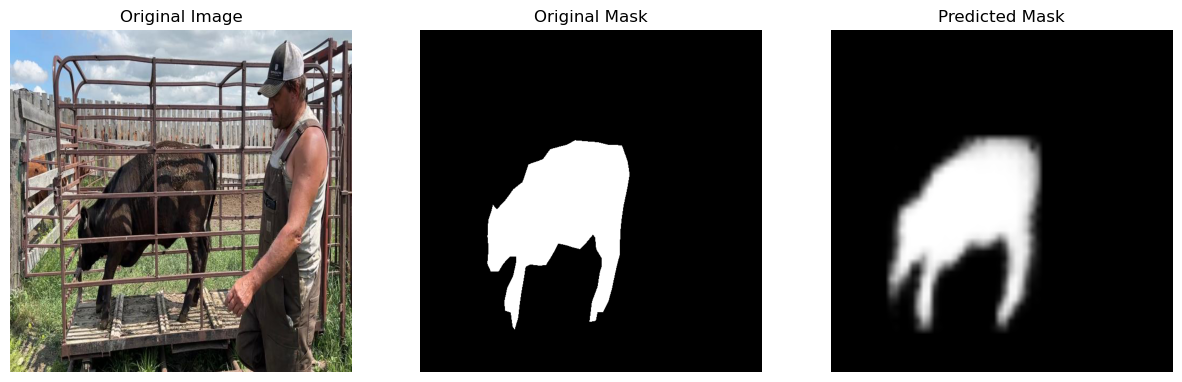

In [9]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Get the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to load an image and mask from the validation dataloader
def load_image_and_mask(dataloader):
    # Get one batch from the dataloader
    img, target = next(iter(dataloader))  # Use next() to get a batch
    return img, target

# Function to plot the images and masks
def plot_results(image, original_mask, predicted_mask):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Original Image
    axs[0].imshow(image.permute(1, 2, 0))  # Convert to HWC format for display
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    # Original Mask
    axs[1].imshow(original_mask, cmap='gray')
    axs[1].set_title("Original Mask")
    axs[1].axis('off')

    # Predicted Mask
    axs[2].imshow(predicted_mask, cmap='gray')
    axs[2].set_title("Predicted Mask")
    axs[2].axis('off')

    plt.show()

# Get a sample image and its target (ground truth) mask
img, target = load_image_and_mask(validation_dataloader)

# Preprocess the image to match the model input format
img_tensor = img[0]  # Take the first image from the batch (no need to unsqueeze)
img_list = [img_tensor.to(device)]  # Wrap in a list and move it to the same device as the model

# Ensure model is in eval mode and move it to the correct device
model.eval()
model.to(device)

# Make predictions (ensure the input is a list)
with torch.no_grad():
    prediction = model(img_list)  # Pass image as a list of 3D tensors
    predicted_masks = prediction[0]['masks']  # Shape: [num_instances, H, W]
    predicted_mask = predicted_masks[0, 0].cpu().numpy()  # Take the first mask

# Get the original mask from the target
original_mask = target['masks'][0, 0].cpu().numpy()  # Ground truth mask

# Plot the results
plot_results(img[0], original_mask, predicted_mask)


Image shape: torch.Size([3, 640, 640])
Original mask shape: (1, 640, 640)
Predicted mask shape: (640, 640)


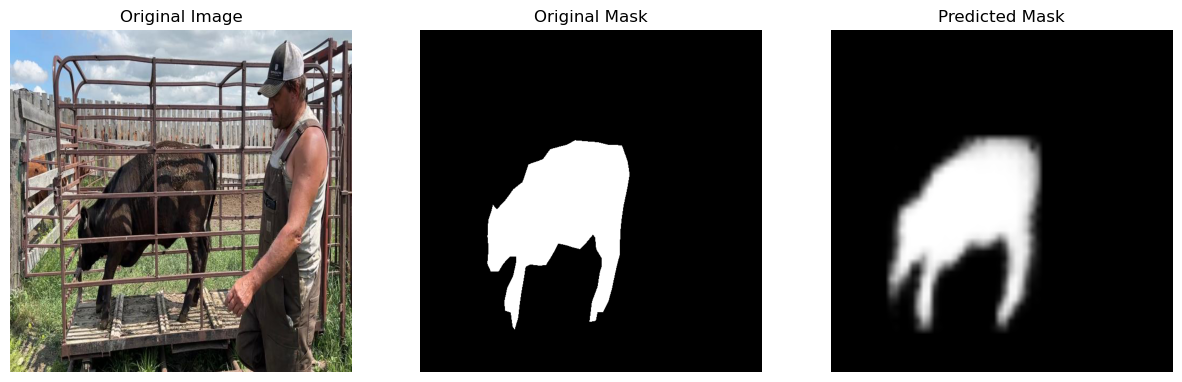

In [10]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import random

# Get the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modified function to load an image and mask from the validation dataloader
def load_image_and_mask(dataloader):
    img, target = next(iter(dataloader))  # Use next() to get a batch
    idx = random.randint(0, len(img) - 1)  # Randomly select an index
    return img[idx], {k: v[idx] for k, v in target.items()}

# Function to plot the images and masks
def plot_results(image, original_mask, predicted_mask):
    # Check shapes
    print(f"Image shape: {image.shape}")
    print(f"Original mask shape: {original_mask.shape}")
    print(f"Predicted mask shape: {predicted_mask.shape}")

    # Ensure original_mask is 2D
    if original_mask.ndim != 2:
        original_mask = np.squeeze(original_mask)
    
    # Ensure predicted_mask is 2D
    if predicted_mask.ndim != 2:
        predicted_mask = np.squeeze(predicted_mask)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(image.permute(1, 2, 0))  # Convert to HWC format for display
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    axs[1].imshow(original_mask, cmap='gray')
    axs[1].set_title("Original Mask")
    axs[1].axis('off')

    axs[2].imshow(predicted_mask, cmap='gray')
    axs[2].set_title("Predicted Mask")
    axs[2].axis('off')

    plt.show()

# Get a sample image and its target (ground truth) mask
img, target = load_image_and_mask(validation_dataloader)

# Preprocess the image to match the model input format
img_tensor = img  # The randomly selected image
img_list = [img_tensor.to(device)]  # Wrap in a list and move it to the same device as the model

# Ensure model is in eval mode and move it to the correct device
model.eval()
model.to(device)

# Make predictions (ensure the input is a list)
with torch.no_grad():
    prediction = model(img_list)  # Pass image as a list of 3D tensors
    predicted_masks = prediction[0]['masks']  # Shape: [num_instances, H, W]
    predicted_mask = predicted_masks[0, 0].cpu().numpy()  # Take the first mask

# Get the original mask from the target
original_mask = target['masks'].cpu().numpy()  # Ground truth mask

# Plot the results
plot_results(img, original_mask, predicted_mask)


Making the mask image as assignment's expected output

Image shape: torch.Size([3, 640, 640])
Original mask shape: (1, 640, 640)
Predicted mask shape: (640, 640)


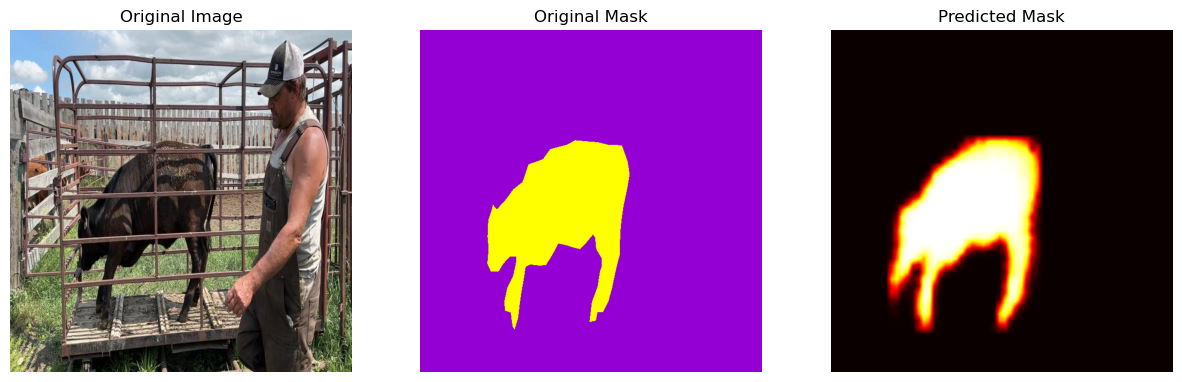

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import random

# Get the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modified function to load an image and mask from the validation dataloader
def load_image_and_mask(dataloader):
    img, target = next(iter(dataloader))  # Use next() to get a batch
    idx = random.randint(0, len(img) - 1)  # Randomly select an index
    return img[idx], {k: v[idx] for k, v in target.items()}

# Function to plot the images and masks
def plot_results(image, original_mask, predicted_mask):
    # Check shapes
    print(f"Image shape: {image.shape}")
    print(f"Original mask shape: {original_mask.shape}")
    print(f"Predicted mask shape: {predicted_mask.shape}")

    # Ensure original_mask is 2D
    if original_mask.ndim != 2:
        original_mask = np.squeeze(original_mask)
    
    # Ensure predicted_mask is 2D
    if predicted_mask.ndim != 2:
        predicted_mask = np.squeeze(predicted_mask)

    # Create a color mask for the original mask
    color_original_mask = np.zeros((original_mask.shape[0], original_mask.shape[1], 3), dtype=np.uint8)
    color_original_mask[original_mask == 1] = [255, 255, 0]  # Yellow for the cow
    color_original_mask[original_mask == 0] = [148, 0, 211]  # Deep violet for the background

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(image.permute(1, 2, 0))  # Convert to HWC format for display
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    axs[1].imshow(color_original_mask)
    axs[1].set_title("Original Mask")
    axs[1].axis('off')

    axs[2].imshow(predicted_mask, cmap='wistia')
    axs[2].set_title("Predicted Mask")
    axs[2].axis('off')

    plt.show()

# Get a sample image and its target (ground truth) mask
img, target = load_image_and_mask(validation_dataloader)

# Preprocess the image to match the model input format
img_tensor = img  # The randomly selected image
img_list = [img_tensor.to(device)]  # Wrap in a list and move it to the same device as the model

# Ensure model is in eval mode and move it to the correct device
model.eval()
model.to(device)

# Make predictions (ensure the input is a list)
with torch.no_grad():
    prediction = model(img_list)  # Pass image as a list of 3D tensors
    predicted_masks = prediction[0]['masks']  # Shape: [num_instances, H, W]
    predicted_mask = predicted_masks[0, 0].cpu().numpy()  # Take the first mask

# Get the original mask from the target
original_mask = target['masks'].cpu().numpy()  # Ground truth mask

# Plot the results
plot_results(img, original_mask, predicted_mask)


c:\Users\washi\anaconda3\envs\PT\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\washi\AppData\Local\Temp\ipykernel_6704\2473523214.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

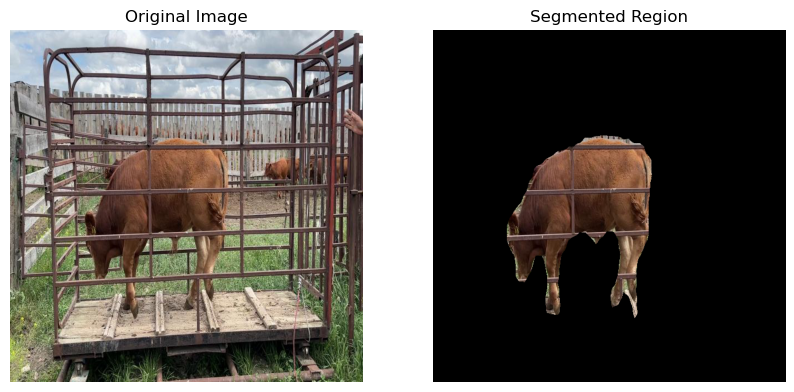

In [12]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Get the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to load an image and preprocess it
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    img_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return img_tensor, image

# Function to extract the segmented region
def extract_segment(image, predicted_mask):
    # Threshold the mask (convert to binary mask)
    binary_mask = (predicted_mask > 0.5).astype(np.uint8)

    # Apply the mask to the original image
    segmented_image = np.array(image) * binary_mask[:, :, None]
    return segmented_image

# Provide the image path
image_path = "C:/Users/washi/Cow_Project/CowSegmentationDataset/test/00071_jpg.rf.1bb7c41398b66a4e0219fa43214bf78d.jpg"  # Update the image path

# Load and preprocess the image
img_tensor, original_image = load_image(image_path)
img_tensor = img_tensor.to(device)

# Initialize and load the trained model
model = models.detection.maskrcnn_resnet50_fpn(pretrained=False)  # Example model, change to your model
num_classes = 2  # Update based on your dataset
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model.roi_heads.mask_predictor = models.detection.mask_rcnn.MaskRCNNPredictor(256, 256, num_classes)
model.load_state_dict(torch.load("C:/Users/washi/Cow_Project/mask_rcnn_cow.pth", map_location=torch.device('cpu')))
model.eval()
model.to(device)

# Make predictions
with torch.no_grad():
    prediction = model(img_tensor)
    predicted_masks = prediction[0]['masks']
    predicted_mask = predicted_masks[0, 0].cpu().numpy()

# Extract the segmented region
segmented_region = extract_segment(original_image, predicted_mask)

# Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_region)
plt.title("Segmented Region")
plt.axis('off')

plt.show()

#trying to remove cage

In [13]:
pip install scikit-image


Note: you may need to restart the kernel to use updated packages.


c:\Users\washi\anaconda3\envs\PT\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\washi\anaconda3\envs\PT\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\washi\AppData\Local\Temp\ipykernel_6704\749203094.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only`

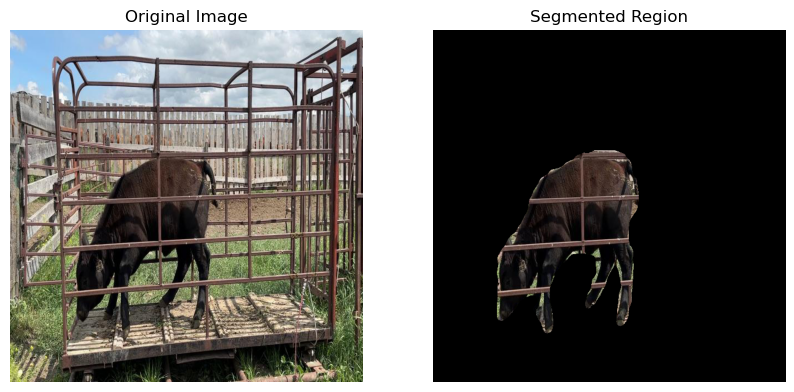

In [14]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from skimage import morphology

# Get the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to load an image and preprocess it
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    img_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return img_tensor, image

# Function to extract the segmented region
def extract_segment(image, predicted_mask):
    # Threshold the mask (convert to binary mask)
    binary_mask = (predicted_mask > 0.5).astype(np.uint8)
    
    # Morphological operations to clean up the mask
    cleaned_mask = morphology.remove_small_objects(binary_mask.astype(bool), min_size=500)
    cleaned_mask = morphology.remove_small_holes(cleaned_mask, area_threshold=500)
    cleaned_mask = morphology.binary_opening(cleaned_mask, morphology.disk(5))
    
    # Apply the cleaned mask to the original image
    segmented_image = np.array(image) * cleaned_mask[:, :, None]
    return segmented_image

# Provide the image path
image_path = "C:/Users/washi/Cow_Project/CowSegmentationDataset/test/frame_261_jpg.rf.f1046b9f3d9eb7727b38041aa246012f.jpg"  # Update the image path

# Load and preprocess the image
img_tensor, original_image = load_image(image_path)
img_tensor = img_tensor.to(device)

# Initialize and load the trained model
model = models.detection.maskrcnn_resnet50_fpn(pretrained=False)  # Example model, change to your model
num_classes = 2  # Update based on your dataset
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model.roi_heads.mask_predictor = models.detection.mask_rcnn.MaskRCNNPredictor(256, 256, num_classes)
model.load_state_dict(torch.load("C:/Users/washi/Cow_Project/mask_rcnn_cow.pth", map_location=torch.device('cpu')))
model.eval()
model.to(device)

# Make predictions
with torch.no_grad():
    prediction = model(img_tensor)
    predicted_masks = prediction[0]['masks']
    predicted_mask = predicted_masks[0, 0].cpu().numpy()

# Extract the segmented region
segmented_region = extract_segment(original_image, predicted_mask)

# Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_region)
plt.title("Segmented Region")
plt.axis('off')

plt.show()


In [1]:
pip install opencv-python-headless


Note: you may need to restart the kernel to use updated packages.


C:\Users\washi\AppData\Local\Temp\ipykernel_11104\1377550154.py:54: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("C:/Users/washi/Cow_Projec

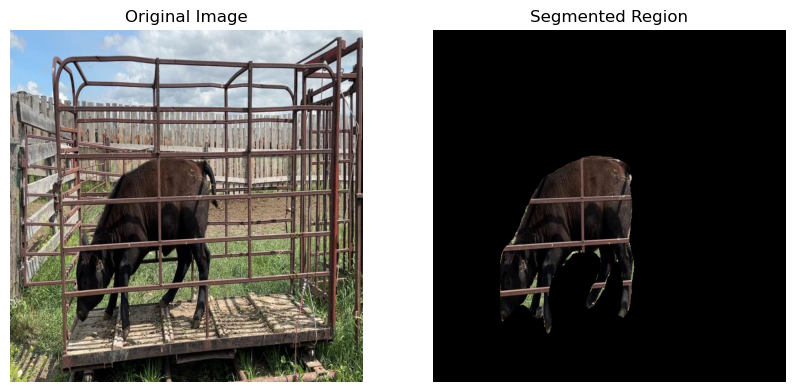

In [19]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2  # OpenCV for contour detection
from skimage import morphology

# Get the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to load an image and preprocess it
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    img_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return img_tensor, image

# Function to extract the segmented region
def extract_segment(image, predicted_mask):
    # Threshold the mask (convert to binary mask)
    binary_mask = (predicted_mask > 0.5).astype(np.uint8)
    
    # Find contours
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create an empty mask for the largest contour
    largest_contour_mask = np.zeros_like(binary_mask)
    
    # Find the largest contour by area and create a mask
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(largest_contour_mask, [largest_contour], -1, 1, thickness=cv2.FILLED)
    
    # Apply the cleaned mask to the original image
    segmented_image = np.array(image) * largest_contour_mask[:, :, None]
    return segmented_image

# Provide the image path
image_path = "C:/Users/washi/Cow_Project/CowSegmentationDataset/test/frame_261_jpg.rf.f1046b9f3d9eb7727b38041aa246012f.jpg"  # Update the image path

# Load and preprocess the image
img_tensor, original_image = load_image(image_path)
img_tensor = img_tensor.to(device)

# Initialize and load the trained model
model = models.detection.maskrcnn_resnet50_fpn(weights=None)  # Updated to use `weights` argument
num_classes = 2  # Update based on your dataset
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model.roi_heads.mask_predictor = models.detection.mask_rcnn.MaskRCNNPredictor(256, 256, num_classes)
model.load_state_dict(torch.load("C:/Users/washi/Cow_Project/mask_rcnn_cow.pth", map_location=torch.device('cpu')), strict=False)
model.eval()
model.to(device)

# Make predictions
with torch.no_grad():
    prediction = model(img_tensor)
    predicted_masks = prediction[0]['masks']
    predicted_mask = predicted_masks[0, 0].cpu().numpy()

# Extract the segmented region
segmented_region = extract_segment(original_image, predicted_mask)

# Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_region)
plt.title("Segmented Region")
plt.axis('off')

plt.show()


In [20]:
model.load_state_dict(torch.load("C:/Users/washi/Cow_Project/mask_rcnn_cow.pth", map_location=torch.device('cpu'), weights_only=True))


<All keys matched successfully>

In [5]:
pip install opencv

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement opencv (from versions: none)
ERROR: No matching distribution found for opencv


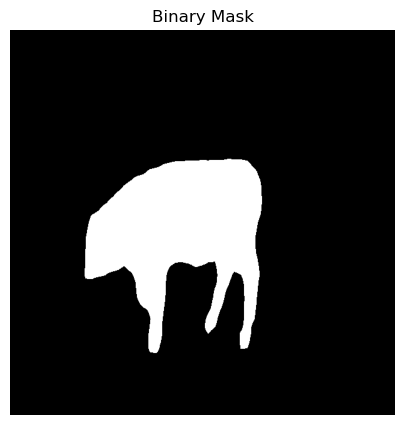

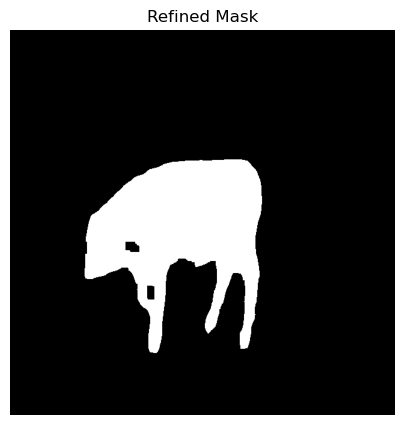

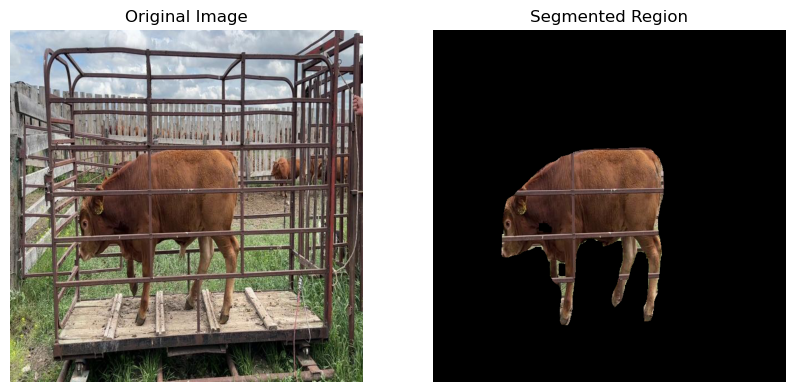

In [26]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2  # Import OpenCV

# Get the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to load an image and preprocess it
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    img_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return img_tensor, image

# Function to apply color and texture filtering
def apply_filters(image, binary_mask):
    # Convert image to HSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    
    # Define color range for cow segmentation
    lower_color = np.array([0, 30, 30])  # Adjust lower bound of cow color in HSV
    upper_color = np.array([30, 255, 255])  # Adjust upper bound of cow color in HSV

    # Color mask
    color_mask = cv2.inRange(hsv_image, lower_color, upper_color)
    
    # Texture filtering using Sobel edge detection
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=5)
    texture_mask = cv2.magnitude(sobelx, sobely)
    _, texture_mask = cv2.threshold(texture_mask, 50, 255, cv2.THRESH_BINARY)
    texture_mask = texture_mask.astype(np.uint8)

    # Combine color and texture masks with the binary mask
    combined_mask = cv2.bitwise_and(binary_mask, binary_mask, mask=color_mask)
    combined_mask = cv2.bitwise_and(combined_mask, combined_mask, mask=texture_mask)
    
    # Use morphological operations to clean up the mask
    kernel = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    return cleaned_mask

# Function to extract the segmented region
def extract_segment(image, predicted_mask):
    # Convert image to numpy array
    img_array = np.array(image)

    # Threshold the mask (convert to binary mask)
    binary_mask = (predicted_mask > 0.5).astype(np.uint8)

    # Debugging: Show the binary mask
    plt.figure(figsize=(5, 5))
    plt.imshow(binary_mask, cmap='gray')
    plt.title("Binary Mask")
    plt.axis('off')
    plt.show()

    # Apply filters
    refined_mask = apply_filters(img_array, binary_mask)
    
    # Apply the refined mask to the original image
    segmented_image = img_array * refined_mask[:, :, None]
    
    # Debugging: Show the refined mask
    plt.figure(figsize=(5, 5))
    plt.imshow(refined_mask, cmap='gray')
    plt.title("Refined Mask")
    plt.axis('off')
    plt.show()

    return segmented_image

# Provide the image path
image_path = "C:/Users/washi/Cow_Project/CowSegmentationDataset/test/00040_jpg.rf.d97109c0162a0b6cfe79e38049a960cf.jpg"  # Update the image path

# Load and preprocess the image
img_tensor, original_image = load_image(image_path)
img_tensor = img_tensor.to(device)

# Initialize and load the trained model
model = models.detection.maskrcnn_resnet50_fpn(weights=None)  # Updated to use `weights` argument
num_classes = 2  # Update based on your dataset
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model.roi_heads.mask_predictor = models.detection.mask_rcnn.MaskRCNNPredictor(256, 256, num_classes)
model.load_state_dict(torch.load("C:/Users/washi/Cow_Project/mask_rcnn_cow.pth", map_location=torch.device('cpu'), weights_only=True))
model.eval()
model.to(device)

# Make predictions
with torch.no_grad():
    prediction = model(img_tensor)
    predicted_masks = prediction[0]['masks']
    predicted_mask = predicted_masks[0, 0].cpu().numpy()

# Extract the segmented region
segmented_region = extract_segment(original_image, predicted_mask)

# Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_region)
plt.title("Segmented Region")
plt.axis('off')

plt.show()


In [3]:
# # Freeze backbone layers if needed
# for param in model.backbone.parameters():
#     param.requires_grad = False


In [4]:
# import torch.optim as optim
# from torch.optim.lr_scheduler import StepLR

# # Define optimizer
# # Only parameters with requires_grad=True will be updated
# params = [p for p in model.parameters() if p.requires_grad]
# optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# # Define learning rate scheduler
# # Reduce LR by a factor of 0.1 every 3 epochs
# lr_scheduler = StepLR(optimizer, step_size=3, gamma=0.1)


In [5]:
# import time
# from tqdm import tqdm  # Progress bar

# def train_one_epoch(model, optimizer, dataloader, device, epoch):
#     """
#     Train the model for one epoch.

#     Args:
#         model: Mask R-CNN model.
#         optimizer: Optimizer.
#         dataloader: DataLoader for the training dataset.
#         device: torch device (CPU or GPU).
#         epoch: Current epoch number.
#     """
#     model.train()  # Set the model to training mode
#     total_loss = 0

#     for images, targets in tqdm(dataloader, desc=f"Epoch {epoch}"):
#         # Move data to the selected device
#         images = [img.to(device) for img in images]
#         targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

#         # Forward pass
#         loss_dict = model(images, targets)

#         # Total loss
#         losses = sum(loss for loss in loss_dict.values())
#         total_loss += losses.item()

#         # Backward pass and optimization
#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()

#     avg_loss = total_loss / len(dataloader)
#     print(f"Epoch {epoch} - Average Loss: {avg_loss:.4f}")

# def train_model(model, optimizer, lr_scheduler, train_loader, valid_loader, device, num_epochs):
#     """
#     Full training loop.

#     Args:
#         model: Mask R-CNN model.
#         optimizer: Optimizer.
#         lr_scheduler: Learning rate scheduler.
#         train_loader: DataLoader for the training dataset.
#         valid_loader: DataLoader for the validation dataset.
#         device: torch device (CPU or GPU).
#         num_epochs: Number of epochs to train.
#     """
#     model.to(device)

#     for epoch in range(1, num_epochs + 1):
#         # Train for one epoch
#         train_one_epoch(model, optimizer, train_loader, device, epoch)

#         # Step the learning rate scheduler
#         lr_scheduler.step()

#         # Save model checkpoint after each epoch
#         torch.save(model.state_dict(), f"mask_rcnn_epoch_{epoch}.pth")
#         print(f"Model checkpoint saved: mask_rcnn_epoch_{epoch}.pth")

#     print("Training complete!")


In [6]:
# def train_one_epoch(model, optimizer, dataloader, device, epoch):
#     model.train()
#     total_loss = 0

#     for images, targets in tqdm(dataloader, desc=f"Epoch {epoch}"):
#         # Debug input shapes
#         print(f"Image shapes: {[img.shape for img in images]}")
#         print(f"Target example: {targets[0]}")

#         # Move data to the device
#         images = [img.to(device) for img in images]
#         targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

#         # Forward pass
#         try:
#             loss_dict = model(images, targets)
#         except Exception as e:
#             print(f"Error during forward pass: {e}")
#             continue

#         losses = sum(loss for loss in loss_dict.values())
#         total_loss += losses.item()

#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()

#     avg_loss = total_loss / len(dataloader)
#     print(f"Epoch {epoch} - Average Loss: {avg_loss:.4f}")


In [7]:
# def validate_dataset(dataset):
#     for i in range(len(dataset)):
#         image, target = dataset[i]
#         boxes = target['boxes']

#         # Ensure boxes are 2D
#         if boxes.ndim == 1:
#             boxes = boxes.unsqueeze(0)  # Convert [4] to [1, 4]

#         # Check if there are any boxes
#         if boxes.size(0) == 0:
#             print(f"No bounding boxes at index {i}.")
#             continue

#         # Validate bounding boxes
#         if not torch.all(boxes[:, 2] > boxes[:, 0]) or not torch.all(boxes[:, 3] > boxes[:, 1]):
#             print(f"Invalid bounding box at index {i}: {boxes}")
#             return False

#         # Validate masks
#         masks = target['masks']
#         if masks.ndim != 3:
#             print(f"Invalid mask dimensions at index {i}: {masks.shape}")
#             return False

#     print("Dataset validation passed.")
#     return True

# # Run validation on the dataset
# validate_dataset(dataset)


In [8]:
# class FixedDataset(torch.utils.data.Dataset):
#     def __init__(self, original_dataset):
#         self.original_dataset = original_dataset

#     def __len__(self):
#         return len(self.original_dataset)

#     def __getitem__(self, idx):
#         image, target = self.original_dataset[idx]

#         # Fix bounding boxes
#         boxes = target['boxes']
#         valid_boxes = []
#         for box in boxes:
#             x1, y1, x2, y2 = box
#             if x2 <= x1 or y2 <= y1:
#                 # Fix invalid coordinates by swapping x1, x2 or y1, y2
#                 x1, x2 = min(x1, x2), max(x1, x2)
#                 y1, y2 = min(y1, y2), max(y1, y2)
#             valid_boxes.append([x1, y1, x2, y2])

#         # Update target with fixed boxes
#         target['boxes'] = torch.tensor(valid_boxes, dtype=torch.float32)

#         return image, target

# # Replace your dataset with the fixed one
# dataset = FixedDataset(dataset)

# # Run validation on the dataset
# validate_dataset(dataset)


In [9]:
# for img, target in dataloader:
#     print(f"Image shape: {img.shape}")
#     print(f"Target: {target}")
#     break


In [10]:
# # Device configuration
# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# # Number of epochs
# num_epochs = 10

# # Initialize DataLoader
# train_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
# valid_loader = None  # If you want to validate, create a DataLoader for the validation set

# # Train the model
# train_model(model, optimizer, lr_scheduler, train_loader, valid_loader, device, num_epochs)
